<a href="https://colab.research.google.com/github/OfirW3/IIoT-NIDS-Technion-ML-Course-Final-Project/blob/main/notebooks/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## === NIDS (Netork Instrusion Detection System) Project by Ofir Weit ===

##Config, Imports and Leakage Filter

In [10]:
# ==========================================
# BLOCK 1.1: MASTER SETUP (Imports, Config & Seeds)
# ==========================================

# --- 1. PYTHON STANDARD LIBRARIES ---
import os
import sys
import re
import gc
import time
import random
import subprocess
import importlib
from datetime import datetime
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display

def now():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# --- 2. MINIMAL AUTO-INSTALLER ---
print(f"[{now()}] Verifying VM environment and installing missing packages...")

# Dictionary mapping 'import_name' -> 'pip_package_name'
required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'joblib': 'joblib',
    'sklearn': 'scikit-learn',
    'xgboost': 'xgboost',
    'tensorflow': 'tensorflow',
    'torch': 'torch',
    'pytorch_tabnet': 'pytorch-tabnet'
}

# Actually execute the installation for missing packages
for import_name, pip_name in required_packages.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"[{now()}] Missing '{import_name}'. Installing '{pip_name}' via pip...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])

# --- 3. ALL THIRD-PARTY IMPORTS ---
print(f"[{now()}] Loading libraries into memory...")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

# ML / DL Models
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

# --- 4. CONFIGURATION ---
DATA_PATH = "/content/drive/MyDrive/CIC_IIOT_2025/cic_iiot_2025_cleaned_and_balanced.csv"
SAVE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Model Specific Configs
N_ESTIMATORS = 100        # For RF/XGB
BATCH_SIZE = 1024         # For TabNet/NN
MAX_EPOCHS = 100          # For TabNet
LATENT_DIM = 32           # For Autoencoder
CONTAMINATION = 0.05      # For Isolation Forest

# --- 5. REPRODUCIBILITY SETUP ---
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds(RANDOM_STATE)

# --- 6. STATUS CHECK ---
print(f"[{now()}] === MASTER SETUP COMPLETE ===")
print(f"   -> Python: {sys.version.split()[0]}")
print(f"   -> TensorFlow: {tf.__version__}")
print(f"   -> PyTorch: {torch.__version__} | Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"   -> Data Path: {DATA_PATH}")

[2026-03-29 13:59:51] Verifying VM environment and installing missing packages...
[2026-03-29 13:59:51] Loading libraries into memory...
[2026-03-29 13:59:51] === MASTER SETUP COMPLETE ===
   -> Python: 3.12.13
   -> TensorFlow: 2.19.0
   -> PyTorch: 2.10.0+cu128 | Device: GPU
   -> Data Path: /content/drive/MyDrive/CIC_IIOT_2025/cic_iiot_2025_cleaned_and_balanced.csv


In [11]:
# ==========================================
# BLOCK 1.2: DATA LOADING & MASTER LEAKAGE FILTER
# ==========================================

print(f"[{now()}] Reading CSV...")
df = pd.read_csv(DATA_PATH, low_memory=False, on_bad_lines="skip")

# --- 1. DEFINE FILTER LISTS ---
FATAL_KEYWORDS = [
    "label", "attack", "class", "category", "status", "ttl", "window", "mss",
    "log_", "fragmentation", "rst", "fin", "flags_avg", "flags_max", "flags_min",
    "flags_std_deviation", "protocol"
]

TOXIC_KEYWORDS = [
    "time", "date", "timestamp", "seq", "ack", "mac", "port", "addr", "id",
    "uuid", "token", "serial", "socket", "session", "device", "host", "ip", "count"
]

SAFE_KEYWORDS = [
    "duration", "interval", "rate", "delta", "mean", "std", "avg", "length", "size",
    "packet", "tcp", "udp", "flag"
]

# --- 2. EXECUTE KEYWORD FILTERING ---
feature_cols, dropped_cols = [], []
print(f"[{now()}] Filtering features by keywords...")

for c in df.columns:
    cl = c.lower().strip()

    # Bypass targets
    if cl in ["label1", "label2"]:
        continue

    # Evaluate keyword conditions
    is_fatal = any(f in cl for f in FATAL_KEYWORDS)
    is_toxic = any(t in cl for t in TOXIC_KEYWORDS)
    is_safe  = any(s in cl for s in SAFE_KEYWORDS)

    # Filter logic
    if is_fatal or (is_toxic and not is_safe):
        dropped_cols.append(c)
    else:
        feature_cols.append(c)

# --- 3. APPLY TO DATAFRAME & REPORT ---
cols_to_keep = feature_cols + [c for c in ["label1", "label2"] if c in df.columns]
df = df[cols_to_keep]

print(f"[{now()}] Filtering Complete.")
print(f"   -> Original Columns: {len(dropped_cols) + len(feature_cols) + (2 if 'label1' in df.columns else 0)}")
print(f"   -> Features Kept:    {len(feature_cols)}")
print(f"   -> Features Dropped: {len(dropped_cols)}")
print(f"   -> Shape of Clean DF:{df.shape}")

print(f"\n[{now()}] FINAL COLUMNS ARRAY AFTER FILTERING:")
print(list(df.columns))

[2026-03-29 13:59:51] Reading CSV...
[2026-03-29 13:59:52] Filtering features by keywords...
[2026-03-29 13:59:52] Filtering Complete.
   -> Original Columns: 94
   -> Features Kept:    29
   -> Features Dropped: 63
   -> Shape of Clean DF:(24888, 31)

[2026-03-29 13:59:52] FINAL COLUMNS ARRAY AFTER FILTERING:
['network_fragmented-packets', 'network_header-length_avg', 'network_header-length_max', 'network_header-length_min', 'network_header-length_std_deviation', 'network_interval-packets', 'network_ip-length_avg', 'network_ip-length_max', 'network_ip-length_min', 'network_ip-length_std_deviation', 'network_packet-size_avg', 'network_packet-size_max', 'network_packet-size_min', 'network_packet-size_std_deviation', 'network_packets_all_count', 'network_packets_dst_count', 'network_packets_src_count', 'network_payload-length_avg', 'network_payload-length_max', 'network_payload-length_min', 'network_payload-length_std_deviation', 'network_tcp-flags-ack_count', 'network_tcp-flags-psh_coun

In [12]:
# ==========================================
# BLOCK 1.3: UNIVERSAL DATA PREP (NESTED SPLIT)
# ==========================================
print(f"\n[{now()}] Preparing Universal Datasets (80/20/20 Split)...")

# 1. Separate Features and Targets
drop_cols = [c for c in ["label1", "label2", "target_bin", "target_multi"] if c in df.columns]
X_raw = df.drop(columns=drop_cols).apply(pd.to_numeric, errors='coerce').fillna(0)

y_bin = (df["label1"].astype(str).str.lower() != "benign").astype(int).values
le_multi = LabelEncoder()
y_multi = le_multi.fit_transform(df["label2"].astype(str).fillna("Unknown"))

# 2. First Split: 80% (Train+Val) and 20% (Test)
X_temp_raw, X_test_raw, y_temp_bin, y_test_bin, y_temp_multi, y_test_multi = train_test_split(
    X_raw, y_bin, y_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bin
)

# 3. Second Split: 80% Train and 20% Validation (from the 80% Train+Val subset)
X_train_raw, X_val_raw, y_train_bin, y_val_bin, y_train_multi, y_val_multi = train_test_split(
    X_temp_raw, y_temp_bin, y_temp_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_temp_bin
)

os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(list(X_train_raw.columns), os.path.join(SAVE_DIR, "training_columns.pkl"))

print(f"[{now()}] Splitting Complete.")
print(f"   -> Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")


[2026-03-29 13:59:52] Preparing Universal Datasets (80/20/20 Split)...
[2026-03-29 13:59:52] Splitting Complete.
   -> Train: 15928 | Val: 3982 | Test: 4978


In [13]:
# ==========================================
# BLOCK 1.4: SAVE TEST DATASET
# ==========================================
print(f"[{now()}] Saving Holdout Test Dataset to Drive...")

TEST_SAVE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"
os.makedirs(TEST_SAVE_DIR, exist_ok=True)
test_save_path = os.path.join(TEST_SAVE_DIR, "test_dataset.csv")

df_test = X_test_raw.copy()
df_test['label1'] = y_test_bin
df_test['label2'] = le_multi.inverse_transform(y_test_multi)
df_test.to_csv(test_save_path, index=False)

print(f"[{now()}] Test dataset successfully isolated and saved to: {test_save_path}")

[2026-03-29 13:59:52] Saving Holdout Test Dataset to Drive...
[2026-03-29 13:59:53] Test dataset successfully isolated and saved to: /content/drive/MyDrive/CIC_IIOT_2025/test_dataset.csv


In [14]:
# ==========================================
# BLOCK 1.5: DATA SCALING
# ==========================================
print(f"[{now()}] Scaling Data...")

scaler = StandardScaler()
# Fit ONLY on training data to prevent leakage
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw) # Scaled but kept in memory out of harm's way

print(f"[{now()}] Scaling Complete.")

[2026-03-29 13:59:53] Scaling Data...
[2026-03-29 13:59:53] Scaling Complete.


##First Random Forest

In [15]:
# ==========================================
# BLOCK 2.1: TRAIN RANDOM FOREST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary Random Forest...")

rf_bin = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_bin.fit(X_train_raw, y_train_bin)

print(f"[{now()}] Binary RF Saved as 'rf_bin'.")

[2026-03-29 13:59:53] Training Binary Random Forest...
[2026-03-29 13:59:54] Binary RF Saved as 'rf_bin'.


[2026-03-29 13:59:54] Evaluating Binary RF on VALIDATION Set...

--- RF Binary Report (Validation) ---
              precision    recall  f1-score   support

      Benign       0.89      0.99      0.94      2189
      Attack       0.98      0.85      0.91      1793

    accuracy                           0.93      3982
   macro avg       0.94      0.92      0.92      3982
weighted avg       0.93      0.93      0.92      3982



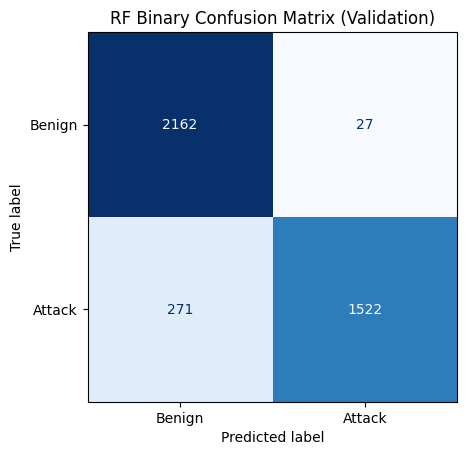

In [16]:
# ==========================================
# BLOCK 2.2: EVALUATE RANDOM FOREST (BINARY)
# ==========================================
print(f"[{now()}] Evaluating Binary RF on VALIDATION Set...")

preds = rf_bin.predict(X_val_raw)
print("\n--- RF Binary Report (Validation) ---")
print(classification_report(y_val_bin, preds, target_names=["Benign", "Attack"]))

ConfusionMatrixDisplay.from_predictions(y_val_bin, preds, display_labels=["Benign", "Attack"], cmap="Blues", colorbar=False)
plt.title("RF Binary Confusion Matrix (Validation)")
plt.show()

[2026-03-29 13:59:54] Visualizing Binary Random Forest Decision Tree...


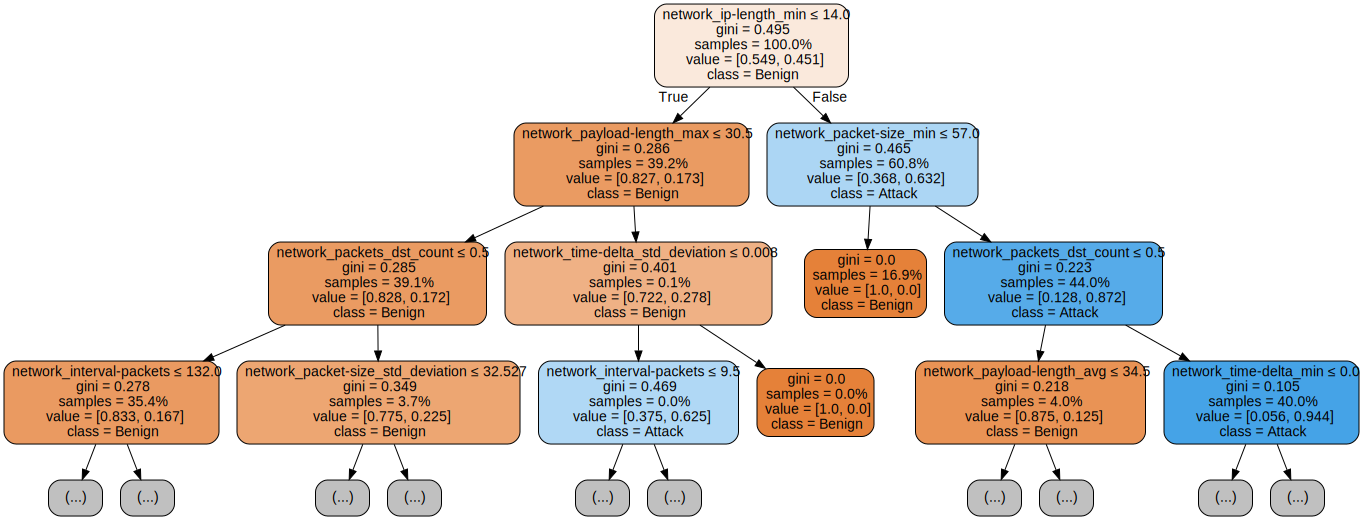

In [17]:
# ==========================================
# BLOCK 2.3: VISUALIZE RANDOM FOREST (BINARY)
# ==========================================
print(f"[{now()}] Visualizing Binary Random Forest Decision Tree...")

# Export the tree logic to Graphviz format
dot_data_bin = export_graphviz(
    rf_bin.estimators_[0],
    out_file=None,
    feature_names=X_train_raw.columns.tolist(),
    class_names=["Benign", "Attack"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3,
    proportion=True # Shows clean percentages instead of massive raw numbers
)

# Render and display the scalable graph
graph_bin = graphviz.Source(dot_data_bin)
display(graph_bin)

In [18]:
# ==========================================
# BLOCK 2.4: TRAIN RANDOM FOREST (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class Random Forest...")

rf_multi = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_multi.fit(X_train_raw, y_train_multi)

print(f"[{now()}] Multi-Class RF Saved as 'rf_multi'.")

[2026-03-29 13:59:54] Training Multi-Class Random Forest...
[2026-03-29 13:59:56] Multi-Class RF Saved as 'rf_multi'.


[2026-03-29 13:59:56] Evaluating Multi-Class RF...

--- RF Multi-Class Report ---
              precision    recall  f1-score   support

      benign       0.90      0.99      0.94      2736
       brute       0.82      0.70      0.76       385
        ddos       0.99      0.87      0.92       367
     malware       0.91      0.84      0.87       371
        mitm       0.82      0.76      0.79       356
       recon       0.93      0.70      0.80       385
         web       0.98      0.85      0.91       378

    accuracy                           0.90      4978
   macro avg       0.91      0.82      0.86      4978
weighted avg       0.90      0.90      0.90      4978



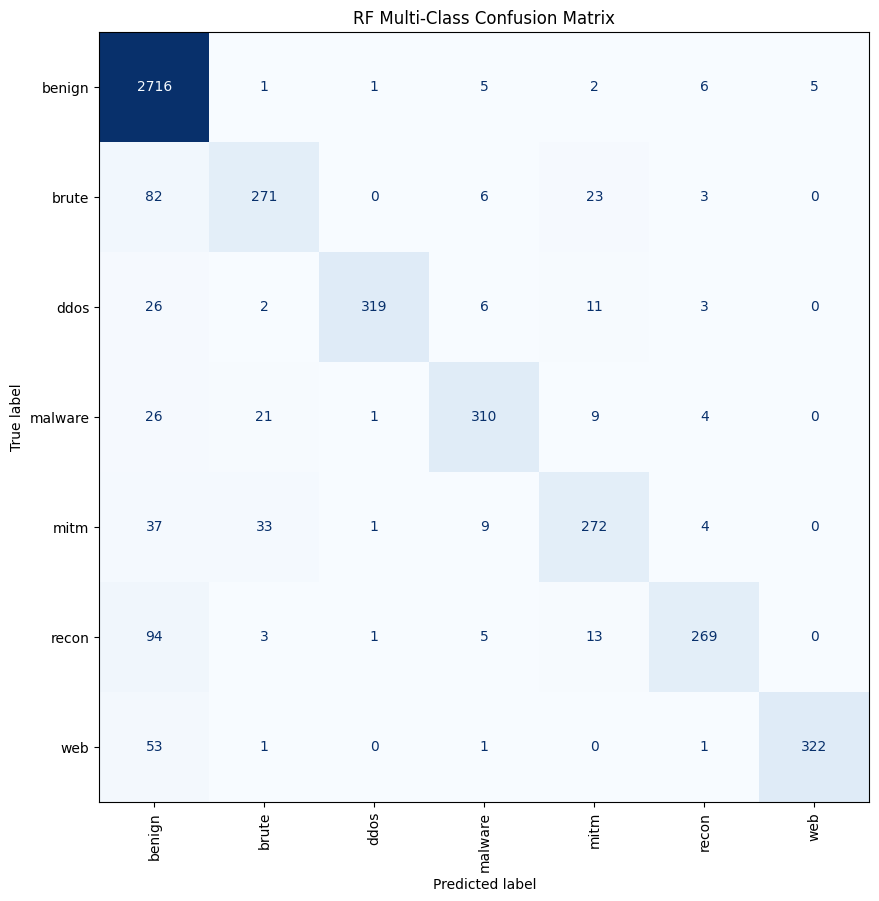

In [19]:
# ==========================================
# BLOCK 2.5: EVALUATE RANDOM FOREST (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class RF...")

preds = rf_multi.predict(X_test_raw)
unique_labels = sorted(set(y_test_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- RF Multi-Class Report ---")
print(classification_report(y_test_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Blues", colorbar=False, ax=ax)
plt.title("RF Multi-Class Confusion Matrix")
plt.show()

[2026-03-29 13:59:56] Visualizing Multi-Class Random Forest Decision Tree...


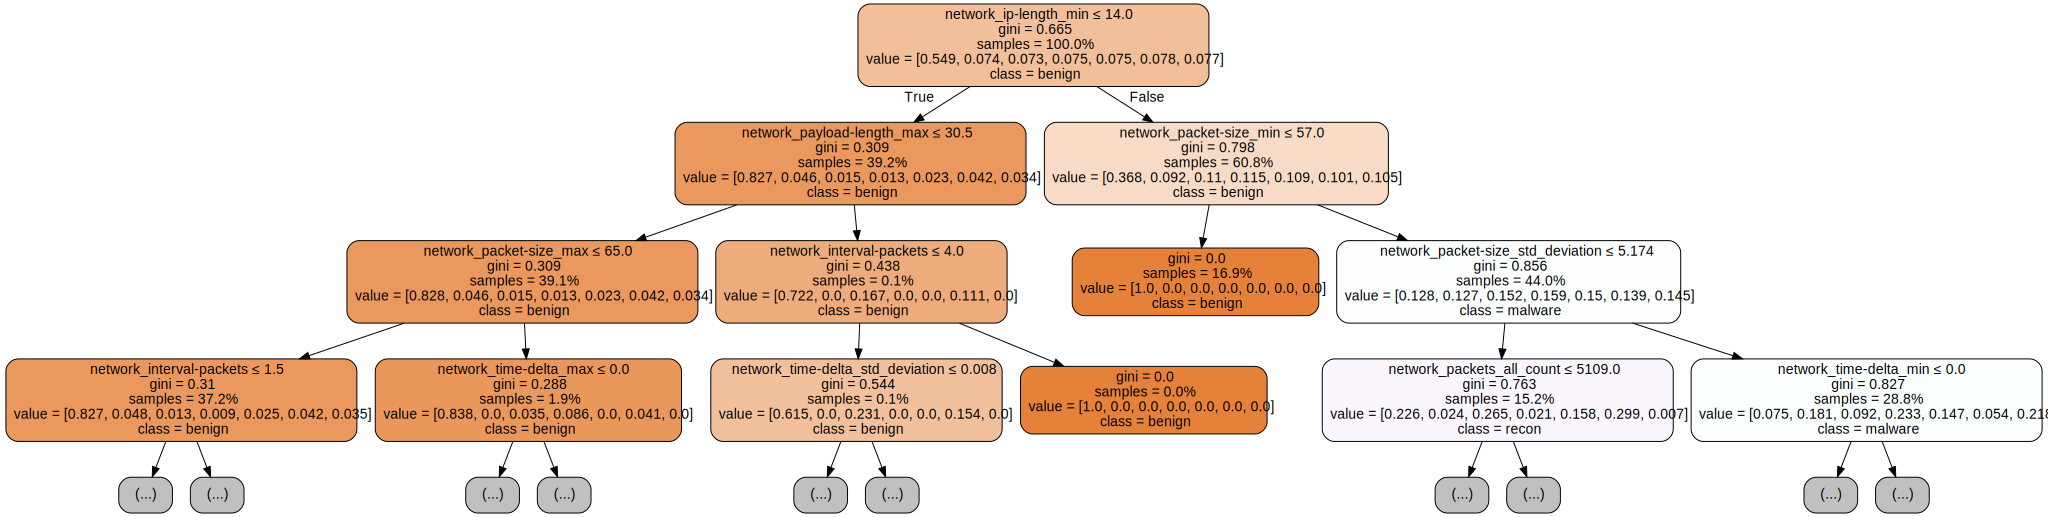

In [20]:
# ==========================================
# BLOCK 2.6: VISUALIZE RANDOM FOREST (MULTI-CLASS)
# ==========================================
print(f"[{now()}] Visualizing Multi-Class Random Forest Decision Tree...")



# Export the tree logic to Graphviz format
dot_data_multi = export_graphviz(
    rf_multi.estimators_[0],
    out_file=None,
    feature_names=X_train_raw.columns.tolist(),
    class_names=le_multi.classes_.tolist(),
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3,
    proportion=True # Crucial here to prevent the massive multi-class arrays from overlapping
)

# Render and display the scalable graph
graph_multi = graphviz.Source(dot_data_multi)
display(graph_multi)

In [21]:
# ==========================================
# BLOCK 2.7: SAVE RANDOM FOREST MODELS
# ==========================================
print(f"[{now()}] Saving Random Forest Models to Drive...")

joblib.dump(rf_bin, os.path.join(SAVE_DIR, "rf_bin_model.pkl"))
joblib.dump(rf_multi, os.path.join(SAVE_DIR, "rf_multi_model.pkl"))

print(f"[{now()}] Random Forest models saved successfully.")

[2026-03-29 13:59:56] Saving Random Forest Models to Drive...
[2026-03-29 13:59:58] Random Forest models saved successfully.


##Neural Network for classifying label1 and label2

In [22]:
# ==========================================
# BLOCK 3.1: TRAIN TABNET (BINARY)
# ==========================================
print(f"[{now()}] Training Binary TabNet (Evaluating on Val Set)...")

tabnet_bin = TabNetClassifier(optimizer_fn=torch.optim.Adam, verbose=1)

tabnet_bin.fit(
    X_train_raw.values, y_train_bin,
    eval_set=[(X_val_raw.values, y_val_bin)],
    max_epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, patience=5
)
print(f"[{now()}] Binary TabNet Saved as 'tabnet_bin'.")

[2026-03-29 13:59:58] Training Binary TabNet (Evaluating on Val Set)...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.66726 | val_0_auc: 0.58984 |  0:00:02s
epoch 1  | loss: 0.52163 | val_0_auc: 0.78883 |  0:00:03s
epoch 2  | loss: 0.47889 | val_0_auc: 0.78907 |  0:00:04s
epoch 3  | loss: 0.45719 | val_0_auc: 0.81073 |  0:00:04s
epoch 4  | loss: 0.4419  | val_0_auc: 0.81341 |  0:00:05s
epoch 5  | loss: 0.44608 | val_0_auc: 0.81889 |  0:00:06s
epoch 6  | loss: 0.45588 | val_0_auc: 0.84913 |  0:00:06s
epoch 7  | loss: 0.43268 | val_0_auc: 0.8413  |  0:00:07s
epoch 8  | loss: 0.41094 | val_0_auc: 0.85165 |  0:00:08s
epoch 9  | loss: 0.40539 | val_0_auc: 0.85732 |  0:00:08s
epoch 10 | loss: 0.39291 | val_0_auc: 0.85802 |  0:00:09s
epoch 11 | loss: 0.38864 | val_0_auc: 0.85754 |  0:00:10s
epoch 12 | loss: 0.37722 | val_0_auc: 0.85774 |  0:00:10s
epoch 13 | loss: 0.37317 | val_0_auc: 0.87521 |  0:00:11s
epoch 14 | loss: 0.37118 | val_0_auc: 0.86977 |  0:00:12s
epoch 15 | loss: 0.36644 | val_0_auc: 0.85075 |  0:00:12s
epoch 16 | loss: 0.36137 | val_0_auc: 0.8498  |  0:00:13s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[2026-03-29 14:00:29] Binary TabNet Saved as 'tabnet_bin'.


[2026-03-29 14:00:29] Evaluating Binary TabNet on VALIDATION Set...

--- TabNet Binary Report (Validation) ---
              precision    recall  f1-score   support

      Benign       0.87      0.96      0.92      2189
      Attack       0.95      0.83      0.88      1793

    accuracy                           0.90      3982
   macro avg       0.91      0.90      0.90      3982
weighted avg       0.91      0.90      0.90      3982



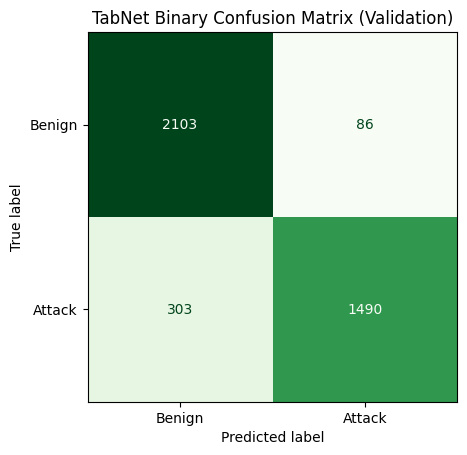

In [23]:
# ==========================================
# BLOCK 3.2: EVALUATE TABNET (BINARY)
# ==========================================
print(f"[{now()}] Evaluating Binary TabNet on VALIDATION Set...")

preds = tabnet_bin.predict(X_val_raw.values)
print("\n--- TabNet Binary Report (Validation) ---")
print(classification_report(y_val_bin, preds, target_names=["Benign", "Attack"]))

ConfusionMatrixDisplay.from_predictions(y_val_bin, preds, display_labels=["Benign", "Attack"], cmap="Greens", colorbar=False)
plt.title("TabNet Binary Confusion Matrix (Validation)")
plt.show()

[2026-03-29 14:00:29] Visualizing Binary TabNet Learning Curves...


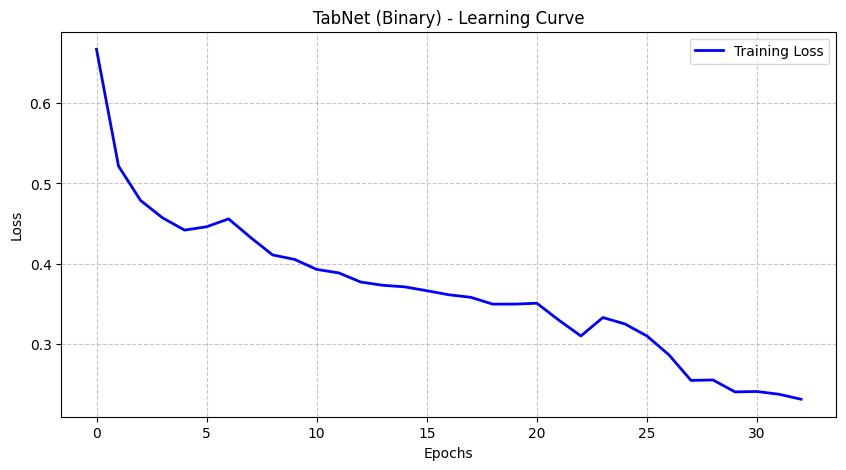

In [24]:
# ==========================================
# BLOCK 3.3: VISUALIZE TABNET LEARNING CURVE (BINARY)
# ==========================================
from datetime import datetime
def now(): return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f"[{now()}] Visualizing Binary TabNet Learning Curves...")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot training loss
plt.plot(tabnet_bin.history['loss'], label='Training Loss', color='blue', linewidth=2)

# Safely look for validation loss without using .keys()
for val_key in ['val_0_loss', 'valid_loss', 'val_loss']:
    try:
        val_data = tabnet_bin.history[val_key]
        if len(val_data) > 0:
            plt.plot(val_data, label='Validation Loss', color='orange', linewidth=2)
            break # Plot only the first one we find and stop searching
    except (KeyError, AttributeError, TypeError):
        pass # If the key doesn't exist, ignore the error and try the next one

plt.title("TabNet (Binary) - Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
# ==========================================
# BLOCK 3.4: TRAIN TABNET (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class TabNet (Evaluating on Val Set)...")

tabnet_multi = TabNetClassifier(optimizer_fn=torch.optim.Adam, verbose=1)

tabnet_multi.fit(
    X_train_raw.values, y_train_multi,
    eval_set=[(X_val_raw.values, y_val_multi)],
    max_epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, patience=5
)
print(f"[{now()}] Multi-Class TabNet Saved as 'tabnet_multi'.")

[2026-03-29 14:00:30] Training Multi-Class TabNet (Evaluating on Val Set)...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.55452 | val_0_accuracy: 0.57986 |  0:00:00s
epoch 1  | loss: 1.2224  | val_0_accuracy: 0.60221 |  0:00:01s
epoch 2  | loss: 1.12787 | val_0_accuracy: 0.63184 |  0:00:02s
epoch 3  | loss: 1.03467 | val_0_accuracy: 0.64314 |  0:00:03s
epoch 4  | loss: 0.98241 | val_0_accuracy: 0.61954 |  0:00:04s
epoch 5  | loss: 0.96626 | val_0_accuracy: 0.61778 |  0:00:05s
epoch 6  | loss: 0.93059 | val_0_accuracy: 0.62155 |  0:00:05s
epoch 7  | loss: 0.91699 | val_0_accuracy: 0.6773  |  0:00:06s
epoch 8  | loss: 0.88931 | val_0_accuracy: 0.66926 |  0:00:07s
epoch 9  | loss: 0.88486 | val_0_accuracy: 0.65143 |  0:00:07s
epoch 10 | loss: 0.86401 | val_0_accuracy: 0.68282 |  0:00:08s
epoch 11 | loss: 0.84589 | val_0_accuracy: 0.67654 |  0:00:09s
epoch 12 | loss: 0.84301 | val_0_accuracy: 0.72024 |  0:00:09s
epoch 13 | loss: 0.81651 | val_0_accuracy: 0.72551 |  0:00:10s
epoch 14 | loss: 0.82038 | val_0_accuracy: 0.73882 |  0:00:11s
epoch 15 | loss: 0.81629 | val_0_accuracy: 0.70492 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[2026-03-29 14:00:51] Multi-Class TabNet Saved as 'tabnet_multi'.


[2026-03-29 14:00:51] Evaluating Multi-Class TabNet on VALIDATION Set...

--- TabNet Multi-Class Report (Validation) ---
              precision    recall  f1-score   support

      benign       0.79      0.95      0.86      2189
       brute       0.44      0.29      0.35       300
        ddos       0.99      0.68      0.80       311
     malware       0.80      0.51      0.62       318
        mitm       0.68      0.52      0.59       291
       recon       0.87      0.57      0.69       283
         web       0.64      0.73      0.68       290

    accuracy                           0.77      3982
   macro avg       0.75      0.61      0.66      3982
weighted avg       0.77      0.77      0.75      3982



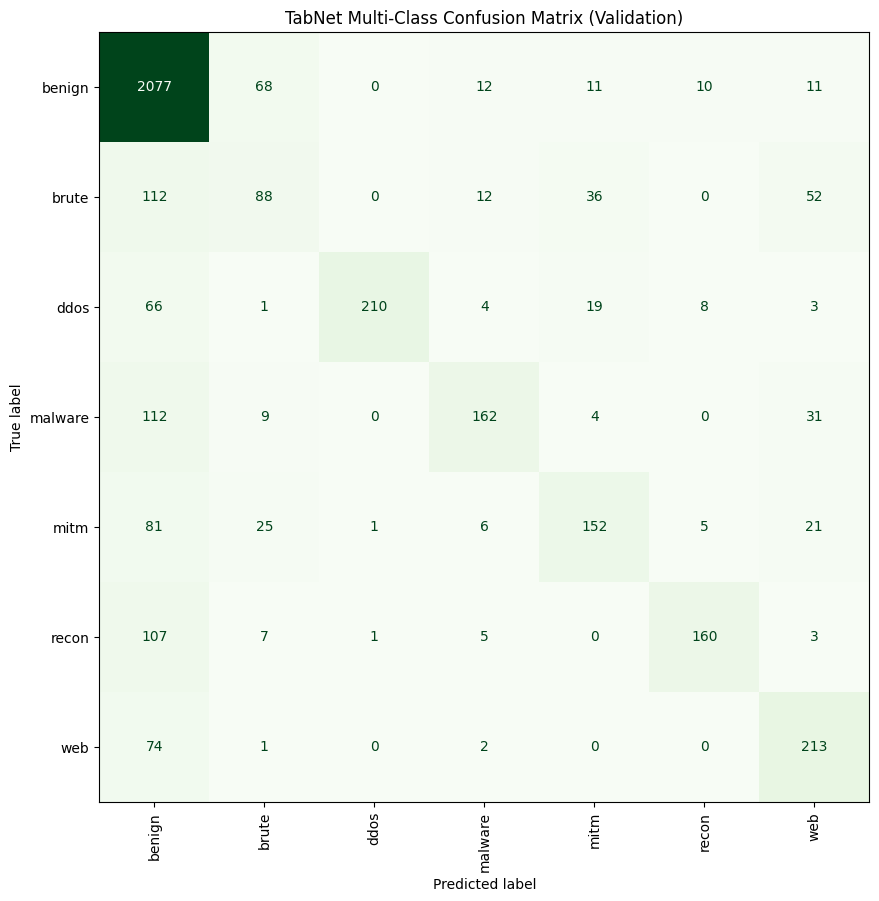

In [26]:
# ==========================================
# BLOCK 3.5: EVALUATE TABNET (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class TabNet on VALIDATION Set...")

preds = tabnet_multi.predict(X_val_raw.values)
unique_labels = sorted(set(y_val_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- TabNet Multi-Class Report (Validation) ---")
print(classification_report(y_val_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_val_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Greens", colorbar=False, ax=ax)
plt.title("TabNet Multi-Class Confusion Matrix (Validation)")
plt.show()

[2026-03-29 14:00:51] Visualizing Multi-Class TabNet Learning Curves...


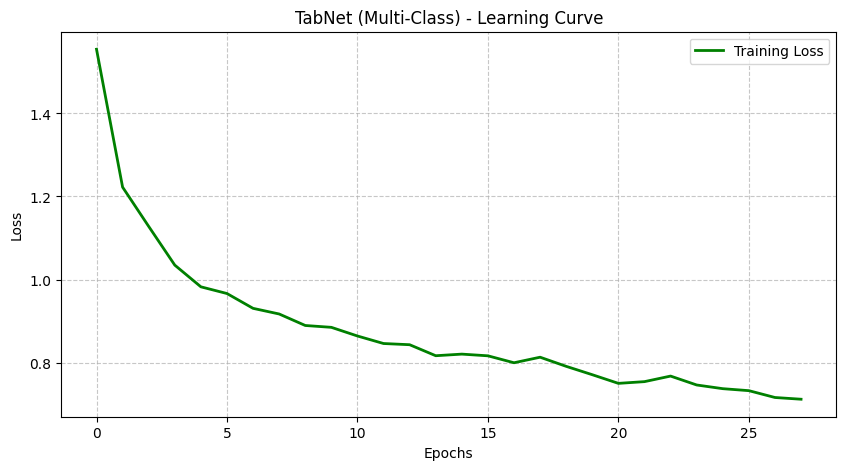

In [27]:
# ==========================================
# BLOCK 3.6: VISUALIZE TABNET LEARNING CURVE (MULTI-CLASS)
# ==========================================
print(f"[{now()}] Visualizing Multi-Class TabNet Learning Curves...")

plt.figure(figsize=(10, 5))

# Plot training loss
plt.plot(tabnet_multi.history['loss'], label='Training Loss', color='green', linewidth=2)

# Safely look for validation loss
for val_key in ['val_0_loss', 'valid_loss', 'val_loss']:
    try:
        val_data = tabnet_multi.history[val_key]
        if len(val_data) > 0:
            plt.plot(val_data, label='Validation Loss', color='red', linewidth=2)
            break
    except (KeyError, AttributeError, TypeError):
        pass

plt.title("TabNet (Multi-Class) - Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [28]:
# ==========================================
# BLOCK 3.7: SAVE TABNET MODELS
# ==========================================
print(f"[{now()}] Saving TabNet Models to Drive...")

SAVE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"
os.makedirs(SAVE_DIR, exist_ok=True)

# TabNet automatically appends '.zip' to the filename
tabnet_bin.save_model(os.path.join(SAVE_DIR, "tabnet_bin_model"))
tabnet_multi.save_model(os.path.join(SAVE_DIR, "tabnet_multi_model"))

print(f"[{now()}] TabNet models saved successfully.")

[2026-03-29 14:00:51] Saving TabNet Models to Drive...
Successfully saved model at /content/drive/MyDrive/CIC_IIOT_2025/tabnet_bin_model.zip
Successfully saved model at /content/drive/MyDrive/CIC_IIOT_2025/tabnet_multi_model.zip
[2026-03-29 14:00:52] TabNet models saved successfully.


##FFNN and XGBoost combination


In [29]:
# ==========================================
# BLOCK 4.1: TRAIN AUTOENCODER (SHARED)
# ==========================================
print(f"[{now()}] Training Autoencoder & Generating Features...")

# Define & Train
input_dim = X_train_scaled.shape[1]
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(32, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='linear')(encoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)
encoder = models.Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=20, batch_size=1024, verbose=0)

# Generate Features ONLY for Train and Val
global_encoder = encoder
X_train_enc = global_encoder.predict(X_train_scaled, verbose=0)
X_val_enc = global_encoder.predict(X_val_scaled, verbose=0)

print(f"[{now()}] Encoder Trained. Validation Features Generated.")

[2026-03-29 14:00:52] Training Autoencoder & Generating Features...
[2026-03-29 14:00:59] Encoder Trained. Validation Features Generated.


In [30]:
# ==========================================
# BLOCK 4.2: TRAIN HYBRID XGBOOST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary XGBoost...")

xgb_bin = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_bin.fit(X_train_enc, y_train_bin)

print(f"[{now()}] Binary XGB Saved as 'xgb_bin'.")

[2026-03-29 14:00:59] Training Binary XGBoost...
[2026-03-29 14:01:01] Binary XGB Saved as 'xgb_bin'.


[2026-03-29 14:01:01] Evaluating Binary XGBoost on VALIDATION Set...

--- Hybrid Binary Report (Validation) ---
              precision    recall  f1-score   support

      Benign       0.85      0.96      0.90      2189
      Attack       0.94      0.79      0.86      1793

    accuracy                           0.88      3982
   macro avg       0.89      0.87      0.88      3982
weighted avg       0.89      0.88      0.88      3982



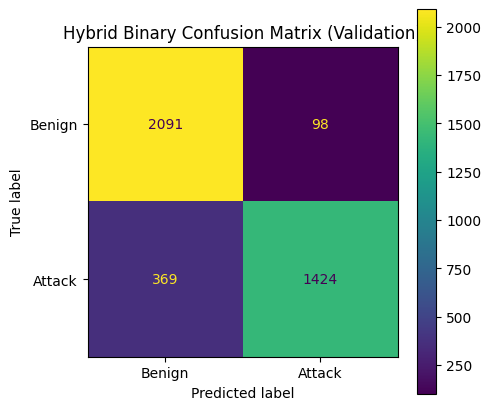

In [31]:
# ==========================================
# BLOCK 4.3: EVALUATE HYBRID XGBOOST (BINARY)
# ==========================================
print(f"[{now()}] Evaluating Binary XGBoost on VALIDATION Set...")

preds = xgb_bin.predict(X_val_enc)

print("\n--- Hybrid Binary Report (Validation) ---")
print(classification_report(y_val_bin, preds, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val_bin,
    preds,
    display_labels=["Benign", "Attack"],
    ax=ax
)
plt.title("Hybrid Binary Confusion Matrix (Validation)")
plt.show()

In [32]:
# ==========================================
# BLOCK 4.4: TRAIN HYBRID XGBOOST (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class XGBoost...")

xgb_multi = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_multi.fit(X_train_enc, y_train_multi)

print(f"[{now()}] Multi-Class XGB Saved as 'xgb_multi'.")

[2026-03-29 14:01:01] Training Multi-Class XGBoost...
[2026-03-29 14:01:05] Multi-Class XGB Saved as 'xgb_multi'.


[2026-03-29 14:01:05] Evaluating Multi-Class XGBoost on VALIDATION Set...

--- Hybrid Multi-Class Report (Validation) ---
              precision    recall  f1-score   support

      benign       0.84      0.97      0.90      2189
       brute       0.63      0.51      0.56       300
        ddos       0.98      0.89      0.93       311
     malware       0.87      0.73      0.80       318
        mitm       0.76      0.63      0.69       291
       recon       0.88      0.56      0.69       283
         web       0.93      0.79      0.86       290

    accuracy                           0.84      3982
   macro avg       0.84      0.73      0.77      3982
weighted avg       0.84      0.84      0.83      3982



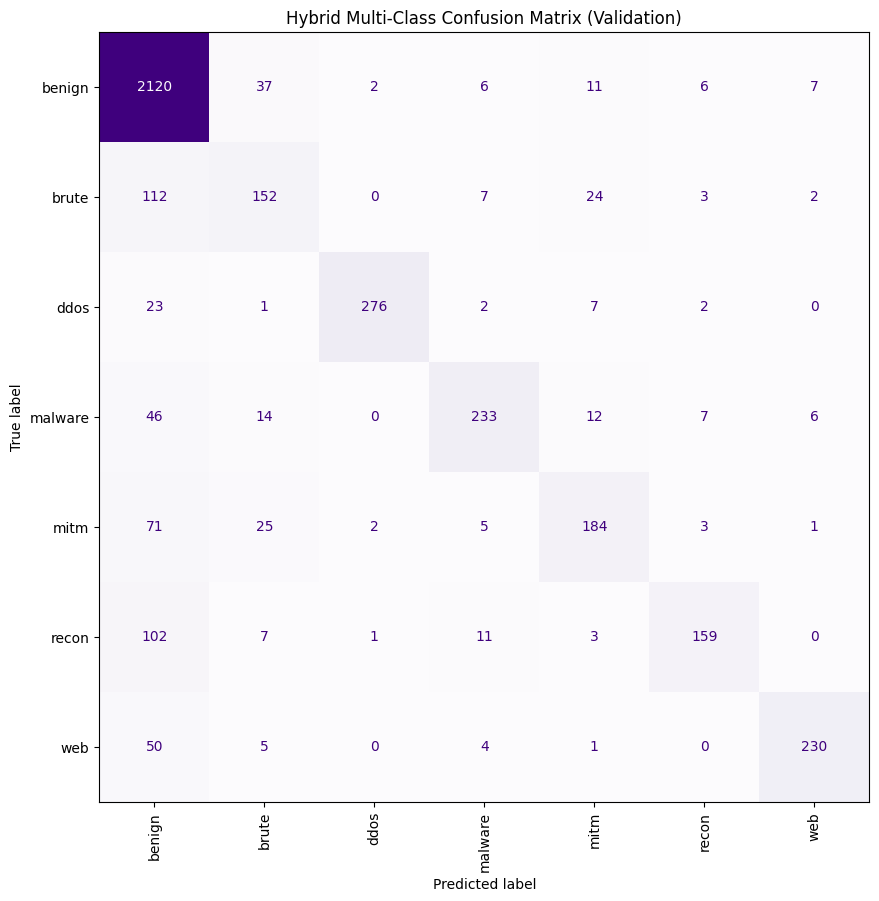

In [33]:
# ==========================================
# BLOCK 4.5: EVALUATE HYBRID XGBOOST (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class XGBoost on VALIDATION Set...")

preds = xgb_multi.predict(X_val_enc)
unique_labels = sorted(set(y_val_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- Hybrid Multi-Class Report (Validation) ---")
print(classification_report(y_val_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_val_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Purples", colorbar=False, ax=ax)
plt.title("Hybrid Multi-Class Confusion Matrix (Validation)")
plt.show()

In [34]:
# ==========================================
# BLOCK 4.6: SAVE AUTOENCODER & ENCODER
# ==========================================
print(f"[{now()}] Saving Autoencoder Models to Drive...")

SAVE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save as native Keras format
autoencoder.save(os.path.join(SAVE_DIR, "autoencoder_model.keras"))
encoder.save(os.path.join(SAVE_DIR, "encoder_model.keras"))

print(f"[{now()}] Autoencoder models saved successfully.")

[2026-03-29 14:01:05] Saving Autoencoder Models to Drive...
[2026-03-29 14:01:06] Autoencoder models saved successfully.


In [35]:
# ==========================================
# BLOCK 4.7: SAVE XGBOOST MODELS
# ==========================================
print(f"[{now()}] Saving Hybrid XGBoost Models to Drive...")

SAVE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Saving as JSON which is the standard for XGBoost
xgb_bin.save_model(os.path.join(SAVE_DIR, "xgb_bin_model.json"))
xgb_multi.save_model(os.path.join(SAVE_DIR, "xgb_multi_model.json"))

print(f"[{now()}] Hybrid XGBoost models saved successfully.")

[2026-03-29 14:01:06] Saving Hybrid XGBoost Models to Drive...
[2026-03-29 14:01:07] Hybrid XGBoost models saved successfully.


##Anomaly detection using Sepration Forest

In [36]:
# ==========================================
# BLOCK 5.1: TRAIN ISOLATION FOREST
# ==========================================
print(f"[{now()}] Training Isolation Forest (Anomaly Detection)...")

if 'X_train_scaled' not in locals(): raise ValueError("Run Block 2.5 first.")

# 1. Filter Train Set -> Keep ONLY Benign (Class 0)
# We use the scaled data from Block 2.5
X_train_benign = X_train_scaled[y_train_bin == 0]

print(f"   -> Training on {len(X_train_benign)} Benign samples only.")

# 2. Train Model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01, # Estimated % of outliers in clean data
    max_features=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

iso_forest.fit(X_train_benign)

print(f"[{now()}] Isolation Forest Saved as 'iso_forest'.")

[2026-03-29 14:01:07] Training Isolation Forest (Anomaly Detection)...
   -> Training on 8755 Benign samples only.
[2026-03-29 14:01:07] Isolation Forest Saved as 'iso_forest'.


[2026-03-29 14:01:07] Evaluating Anomaly Detection on VALIDATION Set...

--- Isolation Forest Report (Validation) ---
                  precision    recall  f1-score   support

 Benign (Normal)       0.61      0.99      0.75      2189
Attack (Anomaly)       0.95      0.22      0.36      1793

        accuracy                           0.64      3982
       macro avg       0.78      0.60      0.55      3982
    weighted avg       0.76      0.64      0.57      3982



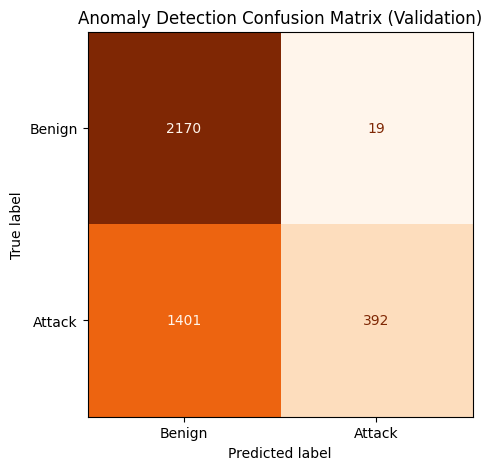

[2026-03-29 14:01:07] Stats:
   -> Total Validation Samples: 3982
   -> Detected Anomalies: 411


In [37]:
# ==========================================
# BLOCK 5.2: EVALUATE ISOLATION FOREST
# ==========================================
print(f"[{now()}] Evaluating Anomaly Detection on VALIDATION Set...")

# 1. Predict (Returns: 1 = Normal, -1 = Anomaly)
preds_raw = iso_forest.predict(X_val_scaled)

# 2. Convert to Binary (0 = Benign, 1 = Attack)
preds_iso = np.where(preds_raw == 1, 0, 1)

# 3. Evaluation Report
print("\n--- Isolation Forest Report (Validation) ---")
print(classification_report(y_val_bin, preds_iso, target_names=["Benign (Normal)", "Attack (Anomaly)"]))

# 4. Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val_bin,
    preds_iso,
    display_labels=["Benign", "Attack"],
    cmap="Oranges",
    colorbar=False,
    ax=ax
)
plt.title("Anomaly Detection Confusion Matrix (Validation)")
plt.show()

# 5. Sanity Check
print(f"[{now()}] Stats:")
print(f"   -> Total Validation Samples: {len(y_val_bin)}")
print(f"   -> Detected Anomalies: {sum(preds_iso)}")

In [38]:
# ==========================================
# BLOCK 5.3: SAVE ISOLATION FOREST
# ==========================================
print(f"[{now()}] Saving Isolation Forest Model to Drive...")

SAVE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(iso_forest, os.path.join(SAVE_DIR, "iso_forest_model.pkl"))

print(f"[{now()}] Isolation Forest model saved successfully.")

[2026-03-29 14:01:07] Saving Isolation Forest Model to Drive...
[2026-03-29 14:01:08] Isolation Forest model saved successfully.


##Save data scaler and label encoder for testing

In [39]:
# ==========================================
# BLOCK 6: SAVE DATA SCALER & LABEL ENCODER
# ==========================================
print(f"[{now()}] Saving Scaler and Label Encoder to Drive...")

SAVE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"
os.makedirs(SAVE_DIR, exist_ok=True)

# It's crucial to save these so you can process new data the exact same way later
joblib.dump(scaler, os.path.join(SAVE_DIR, "standard_scaler.pkl"))
joblib.dump(le_multi, os.path.join(SAVE_DIR, "label_encoder_multi.pkl"))

print(f"[{now()}] Preprocessing objects saved successfully.")

[2026-03-29 14:01:08] Saving Scaler and Label Encoder to Drive...
[2026-03-29 14:01:09] Preprocessing objects saved successfully.
